In [1]:
!nvidia-smi

Thu May 28 10:04:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.49                 Driver Version: 596.49         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070      WDDM  |   00000000:07:00.0  On |                  N/A |
|  0%   41C    P8             23W /  270W |    1595MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, RFE, SequentialFeatureSelector
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

In [3]:
import functions_file_3
from functions_file_3 import *

In [4]:
df = pd.read_csv("ICEV_modeling_ready.csv")
df = df.drop(columns={'Unnamed: 0'})
df = df.dropna()

# PREP

In [5]:
TARGET = 'encon'
TEMPORAL_COL = 'timestamp'
ID_COLS = ['vehid', 'trip']
NUMERIC_COLS = ["speed_kmh", "temp_degc", "displacement", "cylinders", "elapsed_min"]
CATEGORICAL_COLS = ["inferred_class", "transmission", "day_of_week", "road_class"]

FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS

In [6]:
# Already run this cell in Random Forest
df["delta_time_sec"] = df.groupby(["vehid", "trip"])["timestamp"].diff().fillna(0).div(1000)
df["accel"] = df.groupby(["vehid", "trip"])["speed_kmh"].diff()/ df["delta_time_sec"].fillna(0)

# Rolling speed (indicates if there's congestion, aggressive driving, transient engine load)
df["speed_roll_mean_10"] = df.groupby(["vehid", "trip"])["speed_kmh"].rolling(10).mean().reset_index(level=[0,1], drop=True)
df["accel_roll_std_10"] = df.groupby(["vehid", "trip"])["accel"].rolling(10).std().reset_index(level=[0,1], drop=True)

# Encode cyclical time
df["day_sin"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["day_cos"] = np.cos(2*np.pi*df["day_of_week"]/7)

TARGET = 'encon'
RF_NUMERIC_COLS = ["speed_kmh", "temp_degc", "displacement", "cylinders", "elapsed_min", "accel", "speed_roll_mean_10", "accel_roll_std_10", "day_sin", "day_cos"]

RF_CATEGORICAL_COLS = ["inferred_class", "transmission", "road_class"]

RF_FEATURE_COLS = RF_NUMERIC_COLS + RF_CATEGORICAL_COLS

In [7]:
# Forward-fill within trip for null speed_roll_mean_10 and accel_roll_std_10
df = df.sort_values(["vehid", "trip", "timestamp"])
df["speed_roll_mean_10"] = (df.groupby(["vehid", "trip"])["speed_kmh"].rolling(10, min_periods=1).mean().reset_index(level=[0,1], drop=True))
df["accel_roll_std_10"] = (df.groupby(["vehid", "trip"])["accel"].rolling(10, min_periods=1).std().reset_index(level=[0,1], drop=True))
# Fill the rest of NaN with instant values
df["speed_roll_mean_10"] = df["speed_roll_mean_10"].fillna(df["speed_kmh"])
df["accel_roll_std_10"]  = df["accel_roll_std_10"].fillna(0)

In [8]:
df["accel"] = df["accel"].fillna(0)

In [9]:
df.isnull().values.any()

np.False_

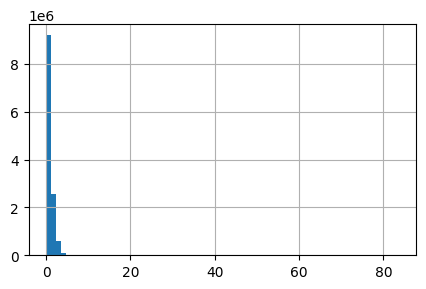

In [10]:
plt.figure(figsize = (5,3))
df["encon"].hist(bins=70)
plt.show()

In [10]:
df["encon_log"] = np.log1p(df["encon"])

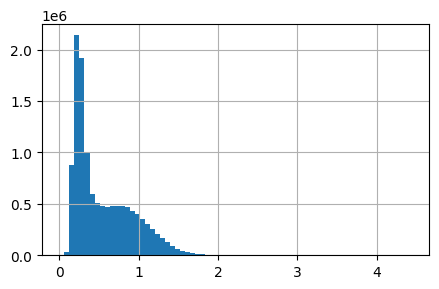

In [12]:
plt.figure(figsize = (5,3))
df["encon_log"].hist(bins=70)
plt.show()

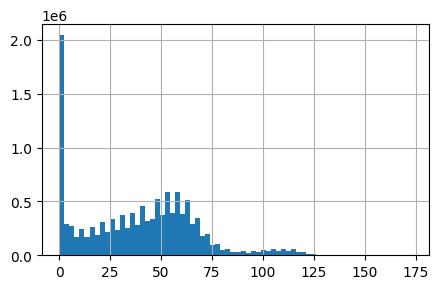

In [13]:
plt.figure(figsize = (5,3))
df["speed_kmh"].hist(bins=70)
plt.show()

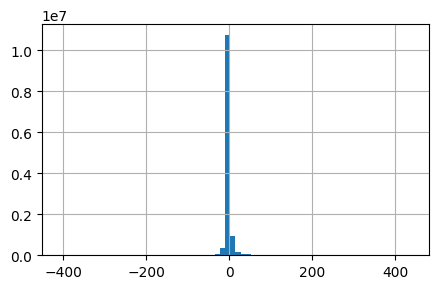

In [14]:
plt.figure(figsize = (5,3))
df["accel"].hist(bins=70)
plt.show()

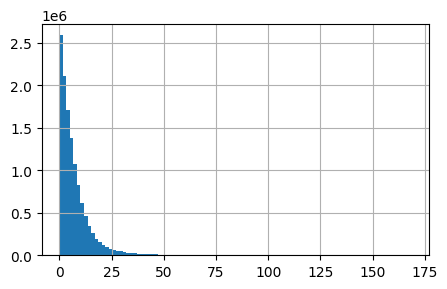

In [15]:
plt.figure(figsize = (5,3))
df["elapsed_min"].hist(bins=100)
plt.show()

In [11]:
df["elapsed_min_log"] = np.log1p(df["elapsed_min"])

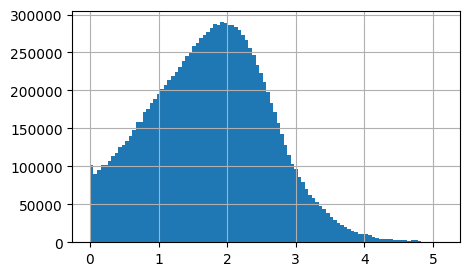

In [17]:
plt.figure(figsize = (5,3))
df["elapsed_min_log"].hist(bins=100)
plt.show()

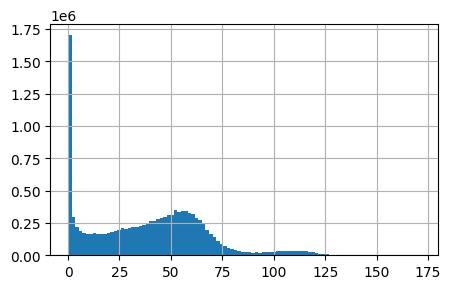

In [18]:
plt.figure(figsize = (5,3))
df["speed_roll_mean_10"].hist(bins=100)
plt.show()

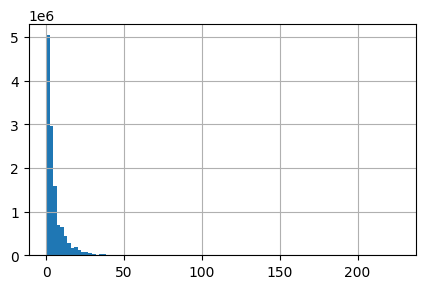

In [19]:
plt.figure(figsize = (5,3))
df["accel_roll_std_10"].hist(bins=100)
plt.show()

In [12]:
df["accel_roll_std_10_log"] = np.log1p(df["accel_roll_std_10"])

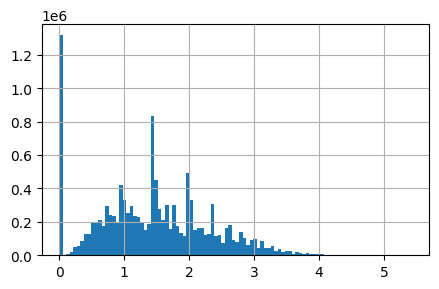

In [21]:
plt.figure(figsize = (5,3))
df["accel_roll_std_10_log"].hist(bins=100)
plt.show()

In [14]:
TARGET = 'encon_log'
TEMPORAL_COL = 'timestamp'
ID_COLS = ['vehid', 'trip']
RF_NUMERIC_COLS = ["speed_kmh", "temp_degc", "displacement", "cylinders", "elapsed_min_log", "accel", "speed_roll_mean_10", "accel_roll_std_10_log", "day_sin", "day_cos"]
RF_CATEGORICAL_COLS = ["inferred_class", "transmission", "road_class"]

RF_FEATURE_COLS = RF_NUMERIC_COLS + RF_CATEGORICAL_COLS

In [13]:
import functions_log
from functions_log import *

In [14]:
train, dev, test = temporal_split(df)

Total rows: 12,493,093
Train: 12,243,231, 98.0%
Dev: 124,931, 1.0%
Test: 124,931, 1.0%


In [15]:
encoders = {}
# Label-encode each categorical column
for col in RF_CATEGORICAL_COLS:
    le = LabelEncoder()
    le.fit(train[col].astype(str))
    encoders[col] = le
    train[col] = le.transform(train[col].astype(str))
    dev[col] = safe_transform(dev[col], le)
    test[col] = safe_transform(test[col], le)

X_train = train[RF_FEATURE_COLS].values
X_dev = dev[RF_FEATURE_COLS].values
X_test = test[RF_FEATURE_COLS].values

y_train = train[TARGET].values
y_dev = dev[TARGET].values
y_test = test[TARGET].values

# StandardScaler (fit on train only)
num_idx = [RF_FEATURE_COLS.index(c) for c in RF_NUMERIC_COLS]
scaler = StandardScaler()
X_train_scaled = X_train.astype(float)
X_dev_scaled = X_dev.astype(float)
X_test_scaled = X_test.astype(float)
X_train_scaled[:, num_idx] = scaler.fit_transform(X_train[:, num_idx])
X_dev_scaled[:, num_idx] = scaler.transform(X_dev[:, num_idx])
X_test_scaled[:, num_idx] = scaler.transform(X_test[:, num_idx])

print(f"Feature matrix shapes for train: {X_train.shape}, dev: {X_dev.shape}, test: {X_test.shape}")
print(f"Target range (train): [{y_train.min():.3f}, {y_train.max():.3f}]  mean={y_train.mean():.3f}")

Feature matrix shapes for train: (12243231, 13), dev: (124931, 13), test: (124931, 13)
Target range (train): [0.000, 4.438]  mean=0.553


In [16]:
print(np.isnan(X_train).any())

False


In [17]:
len(RF_FEATURE_COLS)

13

# XGBoost

In [28]:
from xgboost import XGBRegressor

In [39]:
xgb = XGBRegressor(n_estimators=800,
                   learning_rate=0.05,
                   max_depth=8,
                   colsample_bytree=0.8,
                   reg_lambda=1.0,
                   tree_method="hist",
                   device="cuda",
                   random_state=12,
                   n_jobs=-1)

xgb.fit(X_train, y_train, eval_set=[(X_dev, y_dev)], verbose=100)

[0]	validation_0-rmse:0.35032
[100]	validation_0-rmse:0.22959
[200]	validation_0-rmse:0.22496
[300]	validation_0-rmse:0.22326
[400]	validation_0-rmse:0.22242
[500]	validation_0-rmse:0.22192
[600]	validation_0-rmse:0.22167
[700]	validation_0-rmse:0.22144
[799]	validation_0-rmse:0.22125


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [40]:
train_pred = xgb.predict(X_train)
result = evaluate("XGBoost on Train set", y_train, train_pred)

XGBoost on Train set
MAE: 0.1685 L/hr
RMSE: 0.2317 L/hr
R-squared: 0.5920
MAPE: 38.68%


In [41]:
dev_pred = xgb.predict(X_dev)
result = evaluate("XGBoost on Dev set", y_dev, dev_pred)

XGBoost on Dev set
MAE: 0.1536 L/hr
RMSE: 0.2213 L/hr
R-squared: 0.6134
MAPE: 35.79%


# XGBoost Tune

In [42]:
import optuna

In [46]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 6, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'tree_method': 'hist',
        'random_state': 42,
        'device': 'cuda',
        'n_jobs': -1}
    
    model = XGBRegressor(**params)
    
    model.fit(X_train, y_train,
        eval_set=[(X_dev, y_dev)],
        verbose=False)
    preds = model.predict(X_dev)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))

    return rmse

In [47]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
print("Best trial:")
trial = study.best_trial
print(f"Value (RMSE): {trial.value}")
print("Params:")
for key, value in trial.params.items():
    print(f"{key}: {value}")

[I 2026-05-28 10:33:21,034] A new study created in memory with name: no-name-baa7ac2d-ab7f-44f3-ad63-5041ae4efe46
[I 2026-05-28 10:34:11,928] Trial 0 finished with value: 0.2213594807385636 and parameters: {'n_estimators': 1000, 'learning_rate': 0.013207243051030266, 'max_depth': 10, 'subsample': 0.7234968913582376, 'reg_lambda': 9.99220327510855, 'reg_alpha': 0.5922669070319605}. Best is trial 0 with value: 0.2213594807385636.
[I 2026-05-28 10:34:38,198] Trial 1 finished with value: 0.22257675145173145 and parameters: {'n_estimators': 1000, 'learning_rate': 0.050637886859029896, 'max_depth': 6, 'subsample': 0.8624837098487732, 'reg_lambda': 0.00120732042954896, 'reg_alpha': 0.003661611387985233}. Best is trial 0 with value: 0.2213594807385636.
[I 2026-05-28 10:39:18,113] Trial 2 finished with value: 0.224550550165995 and parameters: {'n_estimators': 1000, 'learning_rate': 0.019844999299067204, 'max_depth': 15, 'subsample': 0.8919670042727461, 'reg_lambda': 0.02307083962652988, 'reg_al

Best trial:
Value (RMSE): 0.22009297311928896
Params:
n_estimators: 600
learning_rate: 0.02821433577257507
max_depth: 12
subsample: 0.5664559782021584
reg_lambda: 0.017933384310185752
reg_alpha: 1.3259819685162693


In [51]:
# Fetch the best parameters discovered by Optuna
best_params = study.best_params

# Ensure fixed technical parameters are included
best_params['tree_method'] = 'hist'
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['device']='cuda'

# Train final tuned model
best_xgb = XGBRegressor(**best_params)
best_xgb.fit(X_train, y_train, eval_set=[(X_dev, y_dev)], verbose=100)

[0]	validation_0-rmse:0.35261
[100]	validation_0-rmse:0.22677
[200]	validation_0-rmse:0.22209
[300]	validation_0-rmse:0.22083
[400]	validation_0-rmse:0.22036
[500]	validation_0-rmse:0.22020
[599]	validation_0-rmse:0.22009


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabet

In [30]:
best_xgb = XGBRegressor(n_estimators=600,
                   learning_rate=0.0282,
                   max_depth=12,
                   subsample=0.5665,
                   reg_lambda=0.01793,
                   reg_alpha=1.325982,
                   tree_method="hist",
                   device="cuda",
                   random_state=12,
                   n_jobs=-1)

best_xgb.fit(X_train, y_train, eval_set=[(X_dev, y_dev)], verbose=100)

[0]	validation_0-rmse:0.35261
[100]	validation_0-rmse:0.22685
[200]	validation_0-rmse:0.22212
[300]	validation_0-rmse:0.22089
[400]	validation_0-rmse:0.22025
[500]	validation_0-rmse:0.22003
[599]	validation_0-rmse:0.21997


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabet

In [31]:
train_pred = best_xgb.predict(X_train)
evaluate("XGBoost Tuned Eval on Train set", y_train, train_pred)

XGBoost Tuned Eval on Train set
MAE: 0.1623 L/hr
RMSE: 0.2240 L/hr
R-squared: 0.6187
MAPE: 37.28%


In [32]:
dev_pred = best_xgb.predict(X_dev)
evaluate("XGBoost Tuned Eval on Dev set", y_dev, dev_pred)

XGBoost Tuned Eval on Dev set
MAE: 0.1526 L/hr
RMSE: 0.2200 L/hr
R-squared: 0.6179
MAPE: 35.45%


# XGBoost SHAP

In [33]:
import shap

In [34]:
idx = np.random.choice(len(X_dev), 1000, replace=False)
if isinstance(X_dev, pd.DataFrame):
    X_shap = X_dev.iloc[idx]
else:
    X_shap = X_dev[idx]

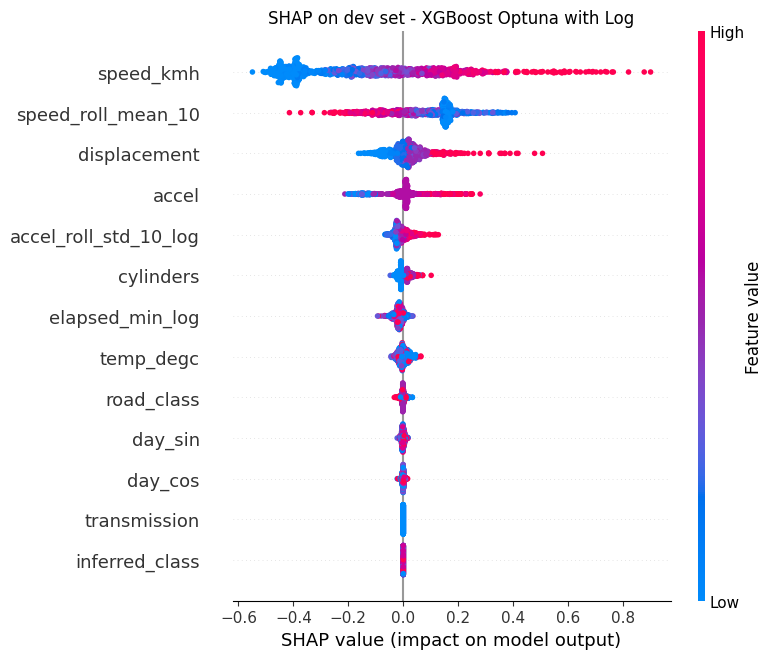

In [35]:
xgb_explainer = shap.TreeExplainer(best_xgb)
xgb_shap_values = xgb_explainer.shap_values(X_shap)
shap.summary_plot(xgb_shap_values, X_shap,
                  feature_names=RF_FEATURE_COLS, show=False)
plt.title(f"SHAP on dev set - XGBoost Optuna with Log")
plt.tight_layout()
plt.show()

# LightGBM

In [47]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [49]:
lgbm = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    device_type="gpu",
    n_jobs=-1)

lgbm.fit(X_train, y_train, 
         eval_set=[(X_dev, y_dev)],
         eval_metric="rmse",
         callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(100)])

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1297
[LightGBM] [Info] Number of data points in the train set: 12243231, number of used features: 12
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3070, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 11 dense feature groups (140.11 MB) transferred to GPU in 0.140612 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 0.552638
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.235091	valid_0's l2: 0.055268
[200]	valid_0's rmse: 0.228232	valid_0's l2: 0.0520899
[300]	valid_0's rmse: 0.225949	valid_0's l2: 0.051053
[400]	valid_0's rmse: 0.224683	valid_0's l2: 0.0504826
[500]	valid_0's rmse: 0.223934	valid_0's l2: 0.0501462
[600]	valid_0's rmse: 0.223455	valid_0's l2: 0.049932
[700]	valid_0's rmse: 0.22

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [50]:
train_pred = lgbm.predict(X_train)
evaluate("LightGBM on Train set", y_train, train_pred)

LightGBM on Train set
MAE: 0.1692 L/hr
RMSE: 0.2324 L/hr
R-squared: 0.5896
MAPE: 38.87%


In [51]:
dev_pred = lgbm.predict(X_dev)
evaluate("LightGBM on Dev set", y_dev, dev_pred)

LightGBM on Dev set
MAE: 0.1535 L/hr
RMSE: 0.2211 L/hr
R-squared: 0.6139
MAPE: 35.78%


In [52]:
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    "device_type": "gpu"}
    
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_dev, label=y_dev, reference=dtrain)
    
    callbacks =[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    
    model = lgb.train(params,
                      dtrain,
                      num_boost_round=1500,  # Max limit; early stopping handles the rest
                      valid_sets=[dval],
                      callbacks=callbacks)
    
    preds = model.predict(X_dev, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))
    
    return rmse

# LightGBM Tune

In [54]:
import optuna

In [55]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
print("Best trial:")
trial = study.best_trial

print(f"Value (RMSE): {trial.value}")
print("Params:")
for key, value in trial.params.items():
    print(f"{key}: {value}")

[I 2026-05-28 11:39:20,838] A new study created in memory with name: no-name-49030a59-f31a-4d0e-b5e0-1c7688181620
[I 2026-05-28 11:45:21,422] Trial 0 finished with value: 0.21980146398619543 and parameters: {'learning_rate': 0.043281517994733225, 'num_leaves': 223, 'max_depth': 13, 'min_child_samples': 330, 'subsample': 0.7741782668809366, 'colsample_bytree': 0.5712111051544566, 'reg_alpha': 0.15543138944338794, 'reg_lambda': 0.1326590793013799}. Best is trial 0 with value: 0.21980146398619543.
[I 2026-05-28 11:46:31,442] Trial 1 finished with value: 0.2209499791952739 and parameters: {'learning_rate': 0.1548187639516971, 'num_leaves': 217, 'max_depth': 13, 'min_child_samples': 274, 'subsample': 0.7124487471101493, 'colsample_bytree': 0.8486484813703088, 'reg_alpha': 0.16358915536876265, 'reg_lambda': 0.01577758970608938}. Best is trial 0 with value: 0.21980146398619543.
[I 2026-05-28 11:47:36,804] Trial 2 finished with value: 0.22061897830958124 and parameters: {'learning_rate': 0.153

Best trial:
Value (RMSE): 0.21980146398619543
Params:
learning_rate: 0.043281517994733225
num_leaves: 223
max_depth: 13
min_child_samples: 330
subsample: 0.7741782668809366
colsample_bytree: 0.5712111051544566
reg_alpha: 0.15543138944338794
reg_lambda: 0.1326590793013799


In [ ]:
best_params = study.best_params
best_params.update({
    'n_estimators': 2000, # Set a high limit and let early stopping trim it
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'device_type': 'gpu'})

In [49]:
best_lgbm = lgb.LGBMRegressor(**best_params)
best_lgbm.fit(X_train, y_train,
    eval_set=[(X_train, y_train), (X_dev, y_dev)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100), 
        lgb.log_evaluation(100)])

Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 0.250121	training's l2: 0.0625603	valid_1's rmse: 0.235982	valid_1's l2: 0.0556875
[200]	training's rmse: 0.239216	training's l2: 0.0572241	valid_1's rmse: 0.226181	valid_1's l2: 0.0511577
[300]	training's rmse: 0.236024	training's l2: 0.0557075	valid_1's rmse: 0.223649	valid_1's l2: 0.0500187
[400]	training's rmse: 0.234178	training's l2: 0.0548395	valid_1's rmse: 0.222227	valid_1's l2: 0.0493847
[500]	training's rmse: 0.233021	training's l2: 0.0542987	valid_1's rmse: 0.221493	valid_1's l2: 0.0490589
[600]	training's rmse: 0.23214	training's l2: 0.053889	valid_1's rmse: 0.220993	valid_1's l2: 0.0488378
[700]	training's rmse: 0.231502	training's l2: 0.0535933	valid_1's rmse: 0.220699	valid_1's l2: 0.0487081
[800]	training's rmse: 0.230982	training's l2: 0.0533528	valid_1's rmse: 0.220563	valid_1's l2: 0.048648
[900]	training's rmse: 0.230503	training's l2: 0.0531317	valid_1's rmse: 0.220407	valid_1's l

,boosting_type,'gbdt'
,num_leaves,223
,max_depth,13
,learning_rate,0.043281517994733225
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,330


In [33]:
train_preds = best_lgbm.predict(X_train)
evaluate("LightGBM Tuned on Train set", y_train, train_preds)

LightGBM Tuned on Train set
MAE: 0.1657 L/hr
RMSE: 0.2283 L/hr
R-squared: 0.6039
MAPE: 38.07%


In [34]:
dev_preds = best_lgbm.predict(X_dev)

In [35]:
evaluate("LightGBM Tuned on Dev set", y_dev, dev_preds)

LightGBM Tuned on Dev set
MAE: 0.1522 L/hr
RMSE: 0.2197 L/hr
R-squared: 0.6187
MAPE: 35.29%


# LightGBM Evaluate

In [23]:
print("Train size:", X_train.shape, "| Dev size:", X_dev.shape)
print("Train target stats:", pd.Series(y_train).describe())
print("Dev target stats:  ", pd.Series(y_dev).describe())

# Check if dev is just an easier distribution
print("\nTrain flow range:", y_train.min(), "–", y_train.max())
print("Dev flow range:", y_dev.min(), "–", y_dev.max())

Train size: (12243231, 13) | Dev size: (124931, 13)
Train target stats: count    1.224323e+07
mean     5.526375e-01
std      3.627498e-01
min      0.000000e+00
25%      2.555667e-01
50%      4.083462e-01
75%      8.089927e-01
max      4.437934e+00
dtype: float64
Dev target stats:   count    124931.000000
mean          0.513756
std           0.355862
min           0.000000
25%           0.242835
50%           0.348474
75%           0.745422
max           2.321022
dtype: float64

Train flow range: 0.0 – 4.437934248575535
Dev flow range: 0.0 – 2.321022012191134


In [28]:
feature_names

['Column_0',
 'Column_1',
 'Column_2',
 'Column_3',
 'Column_4',
 'Column_5',
 'Column_6',
 'Column_7',
 'Column_8',
 'Column_9',
 'Column_10',
 'Column_11',
 'Column_12']

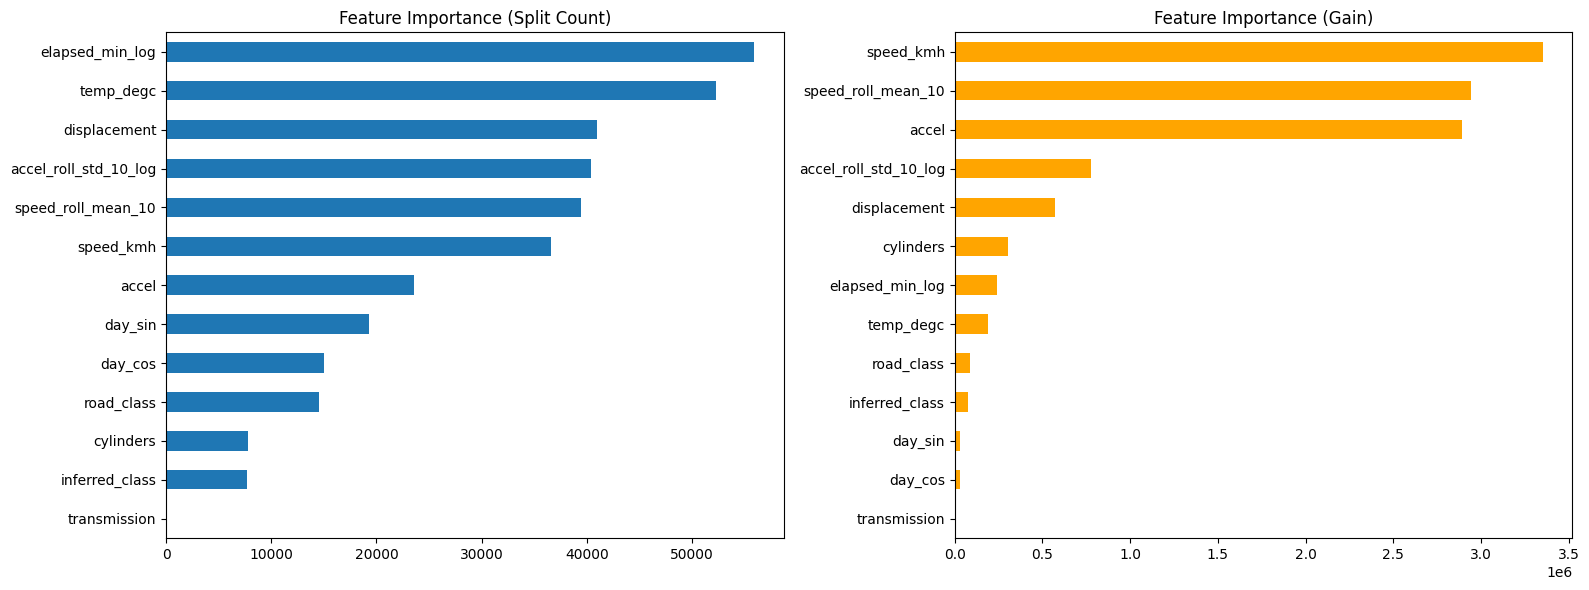


1 zero-importance features: ['transmission']


In [30]:
# --- Split-based importance (default) ---
fi_split = pd.Series(best_lgbm.feature_importances_, index=RF_FEATURE_COLS).sort_values(ascending=False)

# --- Gain-based importance ---
fi_gain = pd.Series(
    best_lgbm.booster_.feature_importance(importance_type='gain'),
    index=RF_FEATURE_COLS
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fi_split.head(20).plot(kind='barh', ax=axes[0], title='Feature Importance (Split Count)')
fi_gain.head(20).plot(kind='barh', ax=axes[1], title='Feature Importance (Gain)', color='orange')
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

zero_importance = fi_split[fi_split == 0]
print(f"\n{len(zero_importance)} zero-importance features:", zero_importance.index.tolist())

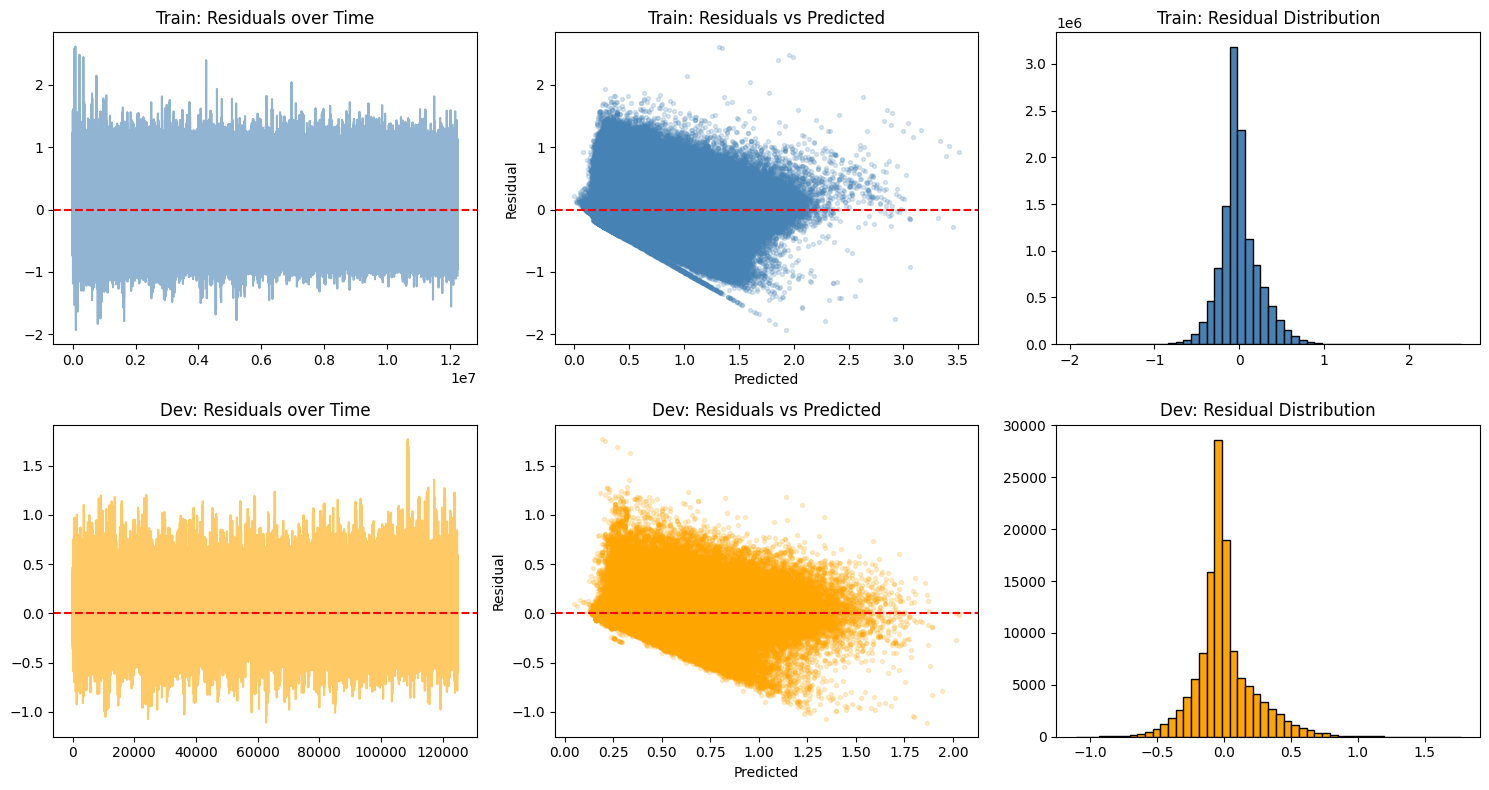

In [36]:
train_resid = y_train - train_preds
dev_resid   = y_dev - dev_preds

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (resid, preds, y_true, label, color) in enumerate([
    (train_resid, train_preds, y_train, 'Train', 'steelblue'),
    (dev_resid,   dev_preds,   y_dev,   'Dev',   'orange')
]):
    axes[row,0].plot(resid, alpha=0.6, color=color)
    axes[row,0].axhline(0, color='r', linestyle='--')
    axes[row,0].set_title(f'{label}: Residuals over Time')

    axes[row,1].scatter(preds, resid, alpha=0.2, s=8, color=color)
    axes[row,1].axhline(0, color='r', linestyle='--')
    axes[row,1].set_title(f'{label}: Residuals vs Predicted')
    axes[row,1].set_xlabel('Predicted'); axes[row,1].set_ylabel('Residual')

    axes[row,2].hist(resid, bins=50, edgecolor='k', color=color)
    axes[row,2].set_title(f'{label}: Residual Distribution')

plt.tight_layout()
plt.show()

In [41]:
df_dev = pd.DataFrame({
    'actual':  pd.Series(y_dev).values,
    'pred':    dev_preds,
    'abs_err': np.abs(pd.Series(y_dev).values - dev_preds),
    'pct_err': np.abs(pd.Series(y_dev).values - dev_preds) / (pd.Series(y_dev).values + 1e-6) * 100})

df_dev['flow_bin'] = pd.cut(df_dev['actual'], bins=8)
print(df_dev.groupby('flow_bin')[['abs_err', 'pct_err']].agg(['mean','count']).round(3))

# What fraction of samples have flow < 0.1 L/hr?
low_flow_pct = (df_dev['actual'] < 0.1).mean() * 100
print(f"\nSamples with flow < 0.1 L/hr: {low_flow_pct:.1f}%")

                 abs_err          pct_err       
                    mean  count      mean  count
flow_bin                                        
(-0.00232, 0.29]   0.100  49332  9278.092  49332
(0.29, 0.58]       0.129  34133    33.372  34133
(0.58, 0.87]       0.169  17917    23.216  17917
(0.87, 1.161]      0.254  14745    25.307  14745
(1.161, 1.451]     0.317   6896    24.847   6896
(1.451, 1.741]     0.381   1638    24.581   1638
(1.741, 2.031]     0.432    250    23.451    250
(2.031, 2.321]     0.605     20    27.823     20

Samples with flow < 0.1 L/hr: 0.1%


Best iteration: 1375 / 2000


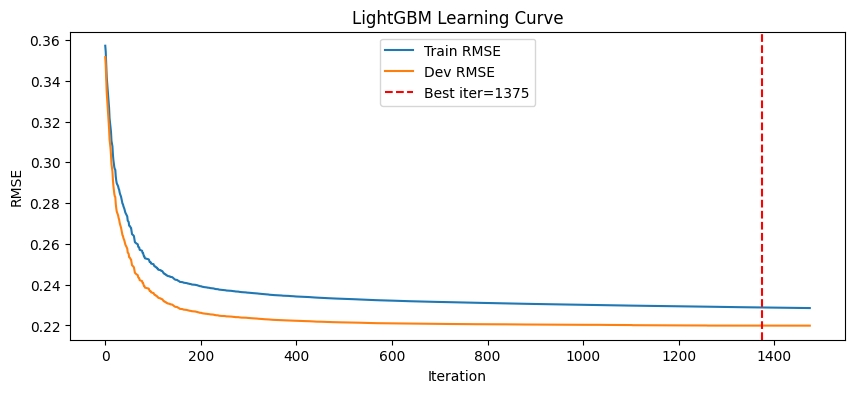

In [54]:
best_iter = best_lgbm.best_iteration_
print(f"Best iteration: {best_iter} / {best_params['n_estimators']}")

# If best_iter is close to n_estimators, your model wanted more trees
if best_iter > 1800:
    print("WARNING: Early stopping didn't trigger => consider increase n_estimators")
elif best_iter < 200:
    print("NOTE: Stopped very early => consider reducing learning_rate")

# Plot eval metric history
results = best_lgbm.evals_result_
plt.figure(figsize=(10, 4))
plt.plot(results['training']['rmse'], label='Train RMSE')
plt.plot(results['valid_1']['rmse'], label='Dev RMSE')
plt.axvline(best_iter, color='r', linestyle='--', label=f'Best iter={best_iter}')
plt.xlabel('Iteration'); plt.ylabel('RMSE')
plt.title('LightGBM Learning Curve')
plt.legend()
plt.show()

In [53]:
print(results.keys())
print({k: list(v.keys()) for k, v in results.items()})

dict_keys(['training', 'valid_1'])
{'training': ['rmse', 'l2'], 'valid_1': ['rmse', 'l2']}


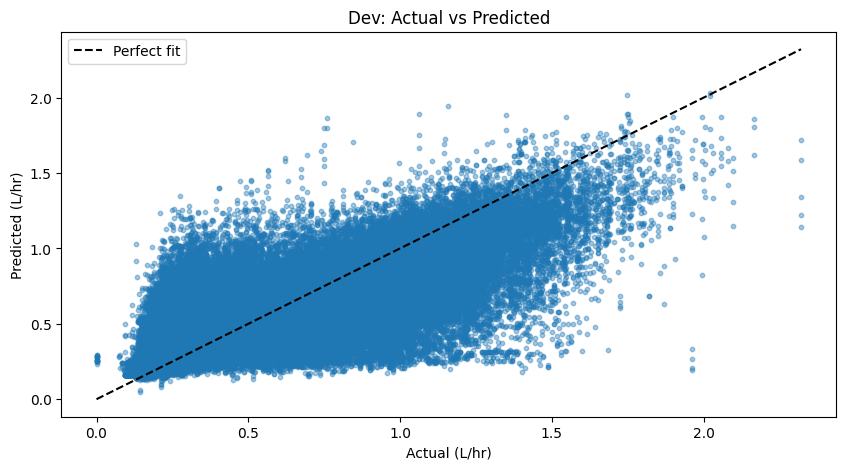

In [47]:
# Actual vs Predicted with error coloring
df_dev['error'] = dev_preds - df_dev['actual']

plt.figure(figsize=(10, 5))
sc = plt.scatter(df_dev['actual'], df_dev['pred'], alpha=0.4, s=10,
                 vmin=-0.5, vmax=0.5)
mn, mx = df_dev['actual'].min(), df_dev['actual'].max()
plt.plot([mn, mx], [mn, mx], 'k--', label='Perfect fit')
plt.xlabel('Actual (L/hr)'); plt.ylabel('Predicted (L/hr)')
plt.title('Dev: Actual vs Predicted')
plt.legend()
plt.show()

# LightGBM SHAP

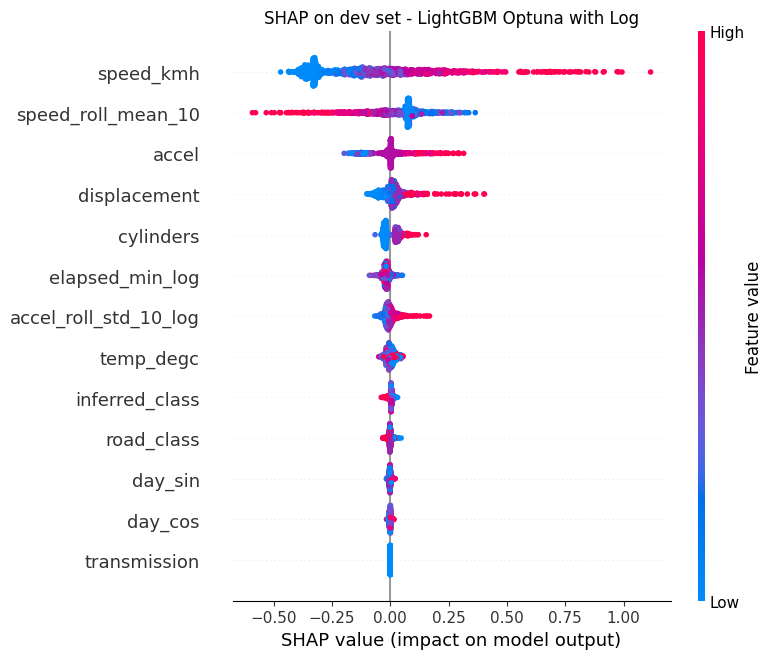

In [60]:
lgbm_explainer = shap.TreeExplainer(best_lgbm)
lgbm_shap_values = lgbm_explainer.shap_values(X_shap)
shap.summary_plot(lgbm_shap_values, X_shap,
                  feature_names=RF_FEATURE_COLS, show=False)
plt.title(f"SHAP on dev set - LightGBM Optuna with Log")
plt.tight_layout()
plt.show()

# LSTM

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [18]:
df_encoded = pd.get_dummies(df, columns=RF_CATEGORICAL_COLS, drop_first=True)
NEW_CATEGORICAL_COLS = [col for col in df_encoded.columns if any(orig in col for orig in RF_CATEGORICAL_COLS)]
LSTM_FEATURES = RF_NUMERIC_COLS + NEW_CATEGORICAL_COLS

In [19]:
# Get all unique combinations of (vehid, trip)
unique_trips = df_encoded[['vehid', 'trip']].drop_duplicates()
unique_trips.shape

(17660, 2)

In [20]:
# Sample trip
sampled_trips = unique_trips.sample(n=5000, random_state=42)
# Filter the main dataframe using merge
df_sampled = df_encoded.merge(sampled_trips, on=['vehid', 'trip'], how='inner')

In [21]:
print(f"Original shape: {df_encoded.shape}")
print(f"Sampled shape: {df_sampled.shape}")
print(f"Unique trips kept: {df_sampled.groupby(['vehid', 'trip']).ngroups}")

Original shape: (12493093, 25)
Sampled shape: (3503143, 25)
Unique trips kept: 5000


In [22]:
train, dev, test = temporal_split(df_sampled)

Total rows: 3,503,143
Train: 3,433,080, 98.0%
Dev: 35,031, 1.0%
Test: 35,032, 1.0%


In [23]:
def scale_features(train, dev, test, numeric_cols, all_cols):
    scaler  = StandardScaler()
    num_idx = [all_cols.index(c) for c in numeric_cols]

    def to_float(df):
        return df[all_cols].values.astype(float)

    X_tr = to_float(train)
    X_dv = to_float(dev)
    X_te = to_float(test)

    X_tr[:, num_idx] = scaler.fit_transform(X_tr[:, num_idx])
    X_dv[:, num_idx] = scaler.transform(X_dv[:, num_idx])
    X_te[:, num_idx] = scaler.transform(X_te[:, num_idx])

    return X_tr, X_dv, X_te, scaler

In [24]:
X_tr, X_dv, X_te, scaler = scale_features(train, dev, test, RF_NUMERIC_COLS, LSTM_FEATURES)
y_tr = train[TARGET].values
y_dv = dev[TARGET].values
y_te = test[TARGET].values
print("Feature Matrix:")
print(f"train: {X_tr.shape}") 
print(f"dev: {X_dv.shape}")
print(f"test: {X_te.shape}")
print("Target Range:")
print(f"train: [{y_tr.min():.3f}, {y_tr.max():.3f}]", f"mean={y_tr.mean():.3f}")

Feature Matrix:
train: (3433080, 16)
dev: (35031, 16)
test: (35032, 16)
Target Range:
train: [0.000, 3.270] mean=0.554


In [25]:
SEQ_LEN = 20       # look-back window (rows).  Tune: 10 / 20 / 50
LSTM_UNITS = [64, 32]
DENSE_UNITS = 32
DROPOUT = 0.1
BATCH_SIZE = 2048
EPOCHS = 50
PATIENCE_ES = 7
PATIENCE_LR = 4
LR = 1e-3

In [26]:
TARGET

'encon_log'

In [27]:
# Creates sequences => ensuring windows do not cross boundaries of different vehicles or trips using strict sequential indices.
def create_sequences_by_trip(df, feature_matrix, target_array, seq_len=20):
    X_seq, y_seq = [], []

    # Map absolute integer positions to rows
    df_pos = df.copy()
    df_pos['row_pos'] = np.arange(len(df))

    grouped = df_pos.groupby(["vehid", "trip"])

    for _, group in grouped:
        positions = group['row_pos'].values

        if len(positions) < seq_len:
            continue
        for i in range(len(positions) - seq_len):
            # Extract exactly seq_len consecutive rows belonging to this trip
            trip_slice_indices = positions[i : i + seq_len]

            # Slice feature matrix using the exact block of indices
            X_seq.append(feature_matrix[trip_slice_indices])

            # Target is the value immediately following the sequence
            target_pos = positions[i + seq_len]
            y_seq.append(target_array[target_pos])

    return np.array(X_seq), np.array(y_seq)

In [28]:
X_tr_seq, y_tr_seq = create_sequences_by_trip(train, X_tr, y_tr, SEQ_LEN)
X_dv_seq, y_dv_seq = create_sequences_by_trip(dev, X_dv, y_dv, SEQ_LEN)
X_te_seq, y_te_seq = create_sequences_by_trip(test, X_te, y_te, SEQ_LEN)

print(f"Train seq shape: {X_tr_seq.shape}")
print(f"Dev seq shape: {X_dv_seq.shape}")
print(f"Test seq shape: {X_te_seq.shape}")

Train seq shape: (3333087, 20, 16)
Dev seq shape: (33194, 20, 16)
Test seq shape: (34092, 20, 16)


In [29]:
model = Sequential([
    LSTM(64,input_shape=(X_tr_seq.shape[1], X_tr_seq.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)])

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          20,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,849 (89.25 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(X_tr_seq, y_tr_seq,
    validation_data=(X_dv_seq, y_dv_seq),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=PATIENCE_ES, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=PATIENCE_LR, min_lr=1e-6)],
    verbose=1)

Epoch 1/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 91s 55ms/step - loss: 0.0712 - val_loss: 0.0675 - learning_rate: 0.0010
Epoch 2/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 90s 55ms/step - loss: 0.0637 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 3/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 91s 56ms/step - loss: 0.0623 - val_loss: 0.0658 - learning_rate: 0.0010
Epoch 4/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 91s 56ms/step - loss: 0.0616 - val_loss: 0.0643 - learning_rate: 0.0010
Epoch 5/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 91s 56ms/step - loss: 0.0610 - val_loss: 0.0639 - learning_rate: 0.0010
Epoch 6/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 91s 56ms/step - loss: 0.0606 - val_loss: 0.0634 - learning_rate: 0.0010
Epoch 7/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 91s 56ms/step - loss: 0.0601 - val_loss: 0.0633 - learning_rate: 0.0010
Epoch 8/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 91s 56ms/step - loss: 0.0598 - val_loss: 0.0636 - learning_rate: 0.0010
Epoch 9/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 92s 56ms/step - loss: 0.0594 - val_loss: 0.063

In [31]:
train_pred = model.predict(X_tr_seq).flatten()
result = evaluate("LSTM", y_tr_seq, train_pred)

104159/104159 ━━━━━━━━━━━━━━━━━━━━ 230s 2ms/step
LSTM
MAE: 0.1745 L/hr
RMSE: 0.2385 L/hr
R-squared: 0.5644
MAPE: 40.38%


In [32]:
dev_pred = model.predict(X_dv_seq).flatten()
result = evaluate("LSTM", y_dv_seq, dev_pred)

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
LSTM
MAE: 0.1772 L/hr
RMSE: 0.2493 L/hr
R-squared: 0.5420
MAPE: 38.81%


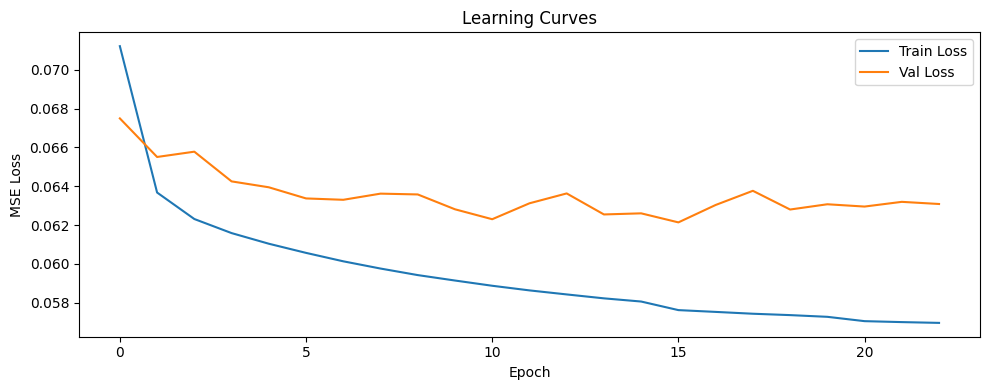

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Learning Curves')
plt.legend()
plt.tight_layout()
plt.show()

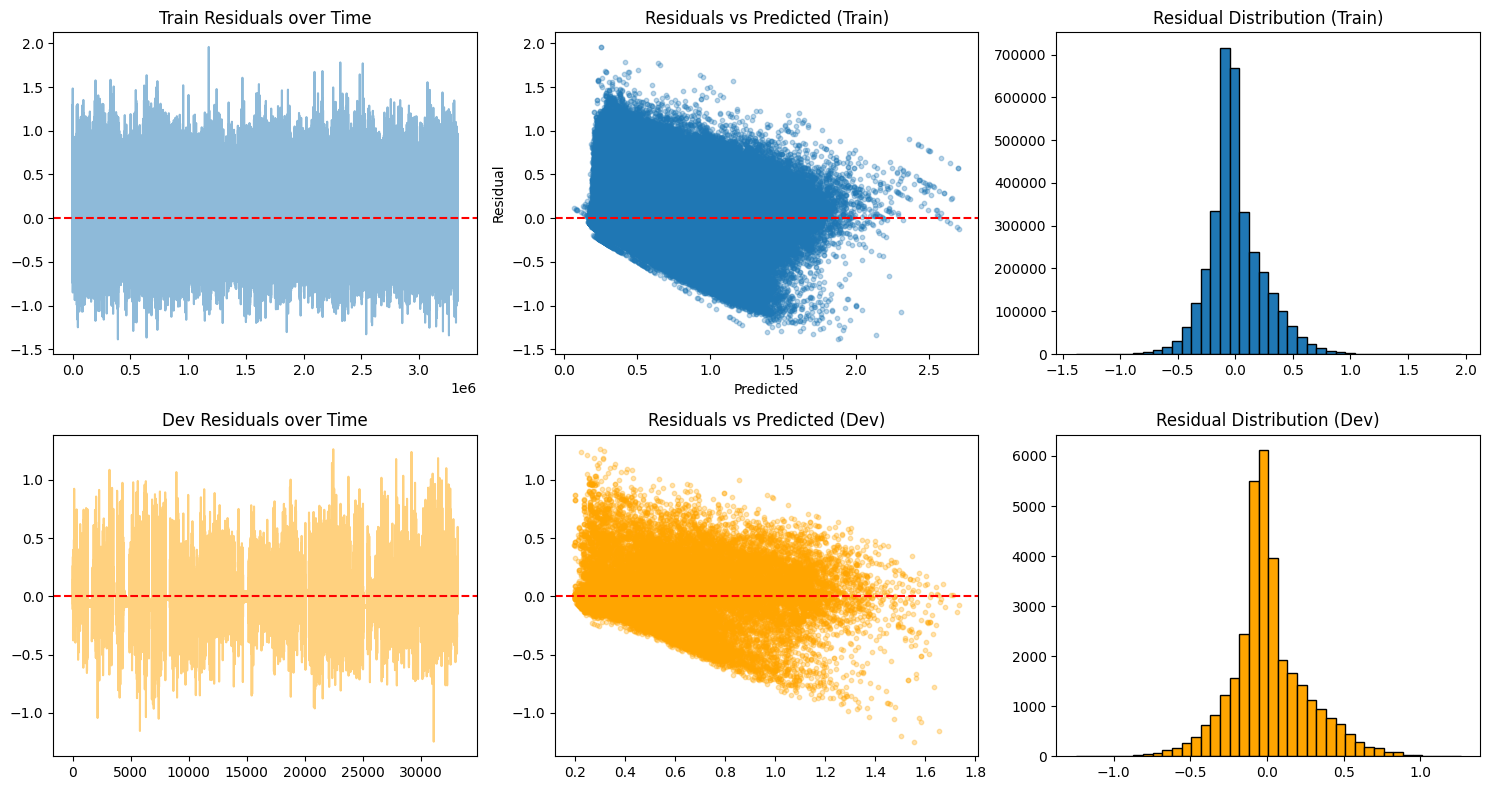

In [34]:
train_resid = y_tr_seq - train_pred
dev_resid   = y_dv_seq - dev_pred

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Residuals over time
axes[0,0].plot(train_resid, alpha=0.5)
axes[0,0].axhline(0, color='r', linestyle='--')
axes[0,0].set_title('Train Residuals over Time')

# Residuals vs predicted (heteroscedasticity check)
axes[0,1].scatter(train_pred, train_resid, alpha=0.3, s=10)
axes[0,1].axhline(0, color='r', linestyle='--')
axes[0,1].set_title('Residuals vs Predicted (Train)')
axes[0,1].set_xlabel('Predicted'); axes[0,1].set_ylabel('Residual')

# Residual distribution
axes[0,2].hist(train_resid, bins=40, edgecolor='k')
axes[0,2].set_title('Residual Distribution (Train)')

# Same for dev
axes[1,0].plot(dev_resid, alpha=0.5, color='orange')
axes[1,0].axhline(0, color='r', linestyle='--')
axes[1,0].set_title('Dev Residuals over Time')

axes[1,1].scatter(dev_pred, dev_resid, alpha=0.3, s=10, color='orange')
axes[1,1].axhline(0, color='r', linestyle='--')
axes[1,1].set_title('Residuals vs Predicted (Dev)')

axes[1,2].hist(dev_resid, bins=40, edgecolor='k', color='orange')
axes[1,2].set_title('Residual Distribution (Dev)')

plt.tight_layout()
plt.show()

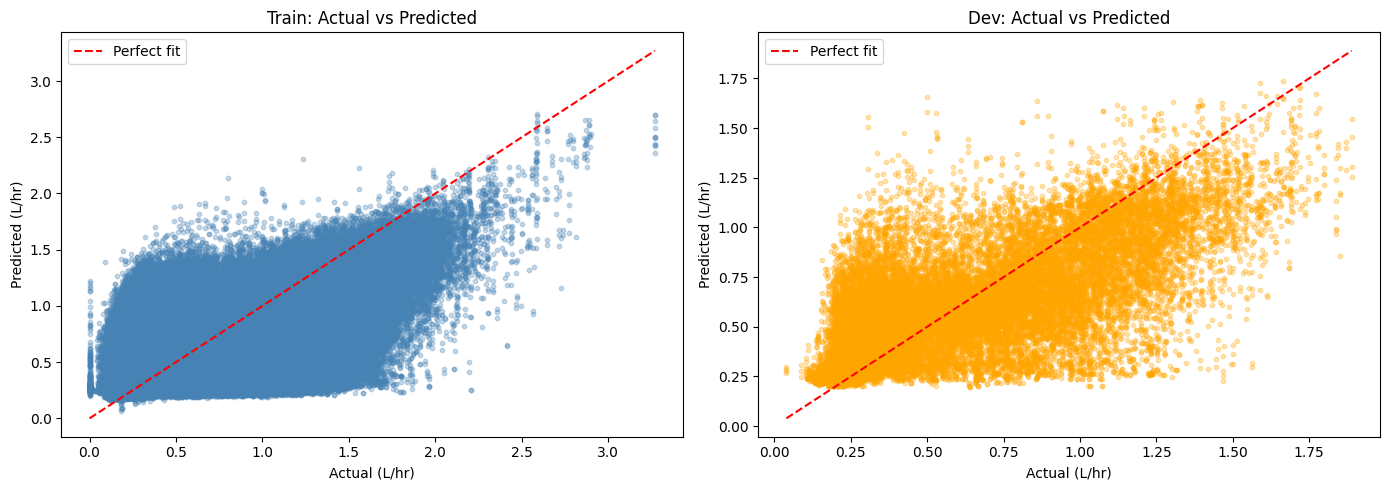

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, label, color in zip(
    axes,
    [y_tr_seq, y_dv_seq],
    [train_pred, dev_pred],
    ['Train', 'Dev'],
    ['steelblue', 'orange']
):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color=color)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', label='Perfect fit')
    ax.set_xlabel('Actual (L/hr)'); ax.set_ylabel('Predicted (L/hr)')
    ax.set_title(f'{label}: Actual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.show()

In [36]:
df_dev = pd.DataFrame({'actual': y_dv_seq, 'pred': dev_pred})
df_dev['abs_err'] = np.abs(df_dev['actual'] - df_dev['pred'])
df_dev['pct_err'] = df_dev['abs_err'] / (df_dev['actual'] + 1e-6) * 100

df_dev['bin'] = pd.cut(df_dev['actual'], bins=8)
print(df_dev.groupby('bin')[['abs_err', 'pct_err']].mean().round(3))

                abs_err  pct_err
bin                             
(0.0372, 0.27]    0.118   56.676
(0.27, 0.502]     0.138   39.224
(0.502, 0.733]    0.163   26.692
(0.733, 0.964]    0.224   26.501
(0.964, 1.195]    0.277   25.994
(1.195, 1.427]    0.343   26.754
(1.427, 1.658]    0.426   28.133
(1.658, 1.889]    0.447   25.701
